[[81.96548045 82.1404535  79.27005083 71.05005445 74.046626  ]
 [60.59726667 62.44406876 52.67940526 85.21524689 83.86965752]
 [48.75796683 63.56430474 67.80668736 62.53793717 67.30195389]
 [48.92385825 54.35380796 61.26447808 58.15934313 61.80097254]
 [74.34712752 68.60796081 70.17485127 75.63800026 65.53747106]
 [59.04506737 72.58002114 68.93290233 72.98027846 70.31508069]
 [79.14249856 67.18005643 77.30701486 72.07479449 65.45729724]
 [84.7682704  76.22252939 76.77416047 65.61431457 74.8697678 ]
 [51.37388891 59.85783707 51.88077093 56.21286045 52.71918494]
 [77.78033877 81.69677625 81.47416142 71.65422722 68.03572543]
 [69.06522004 62.4236184  68.16924076 61.22077789 62.54516938]
 [51.55853386 67.54409441 59.47451029 64.02780178 64.49791458]
 [65.21668533 61.48624923 68.98655844 56.03042962 59.15702027]
 [85.3268166  84.16243266 77.27001366 83.60977802 75.68739287]
 [65.79151118 65.6195584  69.76976761 63.27783924 66.49196368]
 [72.3366973  64.70214069 75.49727178 55.21829488 60.20

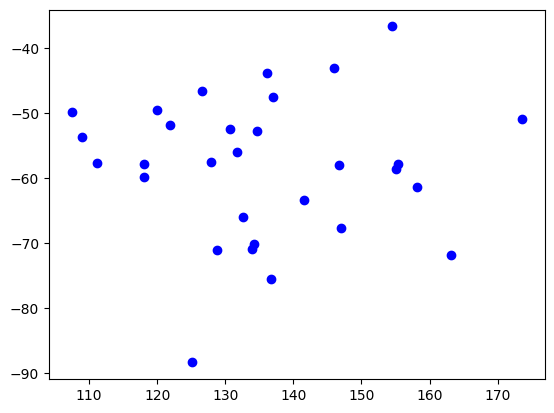

In [28]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt 

n = 30

tec = np.random.normal(70, 10,n)                   # np.random.normal(media,desviacion,n)
crea = np.random.normal(65,10,n)

x1 = tec + np.random.normal(0,5,n)
x2 = tec + np.random.normal(0,5,n)
x3 = tec + np.random.normal(0,5,n)

x4 = crea  + np.random.normal(0,5,n)
x5 = crea + np.random.normal(0,5,n)

X = np.vstack([x1,x2,x3,x4,x5]).T      # vertical stack apilando arreglos
print(X)
u = np.mean(X,axis=0)
X_ = X - u                               # X- u   centrado de datos
cov = X_.T @ X_/n                        # COVARIANZA
print(cov)
val , vec = np.linalg.eig(cov)          # valores y vectores propios
arr = [1,4,2]
def ordenar_indices(arr):              # ordena y obtiene los indices 
    n = len(arr)
    ind = list(range(n))
    arr_ = arr.copy()
    for i in range(n-2,-1,-1):
        a = arr_[i]
        id_ = ind[i]
        j = i + 1
        while j<=n-1 and arr_[j]>a:
            arr_[j - 1] = arr_[j]
            ind[j - 1] = ind[j]
            j = j + 1
        arr_[j - 1] = a
        ind[j - 1] = id_
    return ind 
inds  = ordenar_indices(val) 
val_ =val[inds]                # lmayor, ...
vec_ = vec[:,inds]             # vmayor, v,,
#Col 1    Col 2    Col 3
#    ┌                          ┐
#    │  2.5      2.0     -3.0    │  <- Fila 1
#    │  3.5      3.0     -2.0   │  <- Fila 2
#Xc =│ -3.5     -2.0      3.0   │  <- Fila 3
#    │ -2.5     -3.0      2.0   │  <- Fila 4
#    └                          ┘ 
#   v1​≈(0.63,0.52,−0.58)
#  PC1​=0.63(Mate)+0.52(Fıˊsica)−0.58(Comunicacioˊn)

# proyeccion 
#  X v1  =   DATOS CENTRADOS (Xc)               PROYECCIÓN PCA (Z)
#    Col 1    Col 2    Col 3               PC1 (Varianza Máx)
#  ┌                          ┐                ┌        ┐
#  │  2.5      2.0     -3.0   │       ─────▶   │  4.36  │  Persona A
#  │  3.5      3.0     -2.0   │0.63    ─────▶  │  4.92  │  Persona B
#  │ -3.5     -2.0      3.0   │0.52    ─────▶  │ -4.98  │  Persona C
#  │ -2.5     -3.0      2.0   │-0.58   ─────▶  │ -4.29  │  Persona D
#  └                          ┘                └        ┘
#    (3D: Espacio original)             (1D: Resumen)
print(vec_[0])
por = [ v/sum(val_) for v in val_] 
print(por)
z1 = X@vec_[:,0]
z2 = X@vec_[:,1]
plt.scatter(z1,z2,color='blue')
plt.show() 